In [3]:
import pandas as pd
import joblib

df = pd.read_csv("../data/processed/phase3_features.csv")

X = df.drop(columns=["label"])
y = df["label"]

model = joblib.load("../model/random_forest_best_model.joblib")

X.head()

,brunet_w,proper_nouns_count,singular_words_count,entity_diversity
0,69.926632,14,60,0.714286
1,80.112603,10,65,0.700000
2,108.411105,28,113,0.607143
3,61.496515,7,59,0.428571
4,80.304810,16,80,0.875000


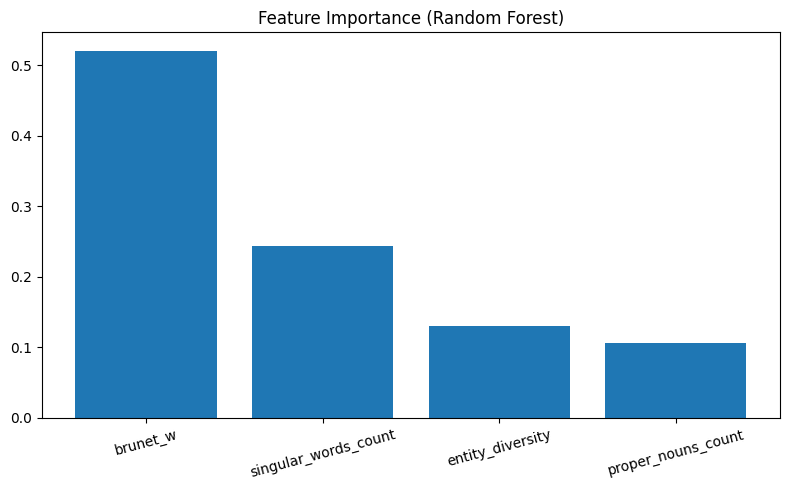

In [4]:
import matplotlib.pyplot as plt
import numpy as np

feature_names = X.columns
importances = model.feature_importances_

indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8, 5))
plt.title("Feature Importance (Random Forest)")
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), feature_names[indices], rotation=15)
plt.tight_layout()
plt.show()

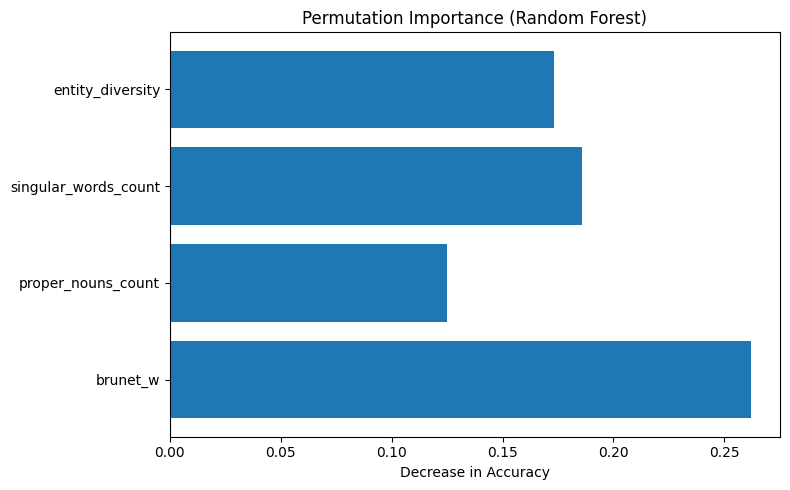

In [6]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    model, X, y, n_repeats=10, random_state=42
)

perm_importance = result.importances_mean

plt.figure(figsize=(8,5))
plt.barh(feature_names, perm_importance)
plt.title("Permutation Importance (Random Forest)")
plt.xlabel("Decrease in Accuracy")
plt.tight_layout()
plt.show()